In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression


from google.colab import files

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [42]:
df = pd.read_csv("clean_data.csv")

print(df.shape)
df.head()

(8005, 60)


,Year,StateAbbr,StateDesc,CountyName,CountyFIPS,LocationName,DataSource,Category,Measure,Data_Value_Unit,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,2018,CA,California,Alameda,6001,6001400100,BRFSS,Health Outcomes,Current asthma among adults aged >=18 years,%,...,0.5,2.2,20.0,34.8,1543.0,80.6,6.6,12.8,0.0,4.0
1,2018,CA,California,Alameda,6001,6001400200,BRFSS,Health Outcomes,Current asthma among adults aged >=18 years,%,...,4.4,5.0,11.8,29.2,1231.0,77.4,10.2,11.6,0.8,3.7
2,2018,CA,California,Alameda,6001,6001400300,BRFSS,Health Outcomes,Current asthma among adults aged >=18 years,%,...,5.4,4.9,10.3,31.3,3213.0,73.0,17.8,9.2,0.0,5.5
3,2018,CA,California,Alameda,6001,6001400400,BRFSS,Health Outcomes,Current asthma among adults aged >=18 years,%,...,4.3,12.8,9.1,30.4,2499.0,73.9,15.2,10.7,0.3,5.0
4,2018,CA,California,Alameda,6001,6001400500,BRFSS,Health Outcomes,Current asthma among adults aged >=18 years,%,...,2.9,11.1,14.0,32.4,2587.0,77.1,14.1,8.8,0.0,2.6


Set Up - Q1

In 2018, what is the causal effect of high predicted PM2.5 levels on adult asthma prevalence in California?

Treatment variable: PM25_Treatment (derived from DS_PM_pred, binarized into "High"/"Low")

Outcome variable: Data_Value (asthma prevalence %, from CDC)

Potential confounders:

Race: White, Black, Hispanic, Asian, Native, Pacific

Gender: Men, Women

Income: Income, Poverty, IncomePerCap, ChildPoverty

Other socioeconomic controls: Employment, Commute, Education proxies (like Professional, Service, Construction, etc.)

This setup is suitable for Inverse Propensity Weighting (IPW) or matching to estimate the Average Treatment Effect (ATE) of high pollution exposure on asthma rates, controlling for those confounders.

Set Up - Q2

Can we predict air pollution levels (PM2.5) using asthma prevalence and socioeconomic/demographic indicators at the Census Block Group level in California (2018)?

Target variable: DS_PM_pred (predicted PM2.5 concentration)

Predictor variables:

Health outcome: Data_Value (asthma prevalence %)

Demographics:

Men, Women

White, Black, Hispanic, Asian, Native, Pacific

Socioeconomic variables:

Income, Poverty, IncomePerCap, ChildPoverty

Professional, Service, Office, Construction, Production

Employed, Unemployment

MeanCommute, Drive, Carpool, Transit, Walk, WorkAtHome

This aligns with exploratory environmental justice questions, for example: “Can we identify disproportionately polluted communities using social indicators and health disparities?”

<div style="page-break-after: always;"></div>

In [43]:
from sklearn.cluster import KMeans

pm_values = df[['DS_PM_pred']].copy()

kmeans = KMeans(n_clusters=2, random_state=42)
df['PM25_Cluster'] = kmeans.fit_predict(pm_values)

centroids = kmeans.cluster_centers_.flatten()
high_cluster = np.argmax(centroids)

df['PM25_Treatment'] = (df['PM25_Cluster'] == high_cluster).astype(int)

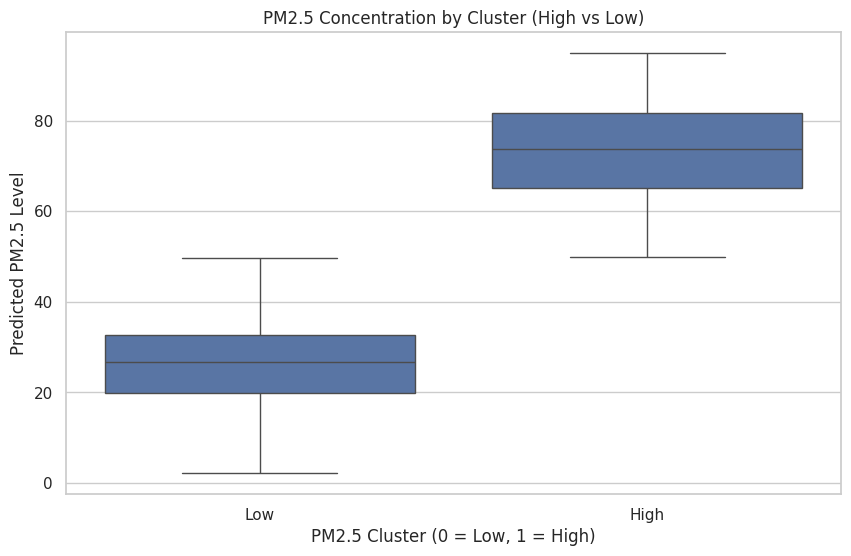

In [44]:
sns.boxplot(x='PM25_Treatment', y='DS_PM_pred', data=df)

plt.title('PM2.5 Concentration by Cluster (High vs Low)')
plt.xlabel('PM2.5 Cluster (0 = Low, 1 = High)')
plt.ylabel('Predicted PM2.5 Level')
plt.xticks([0, 1], ['Low', 'High'])

plt.show()

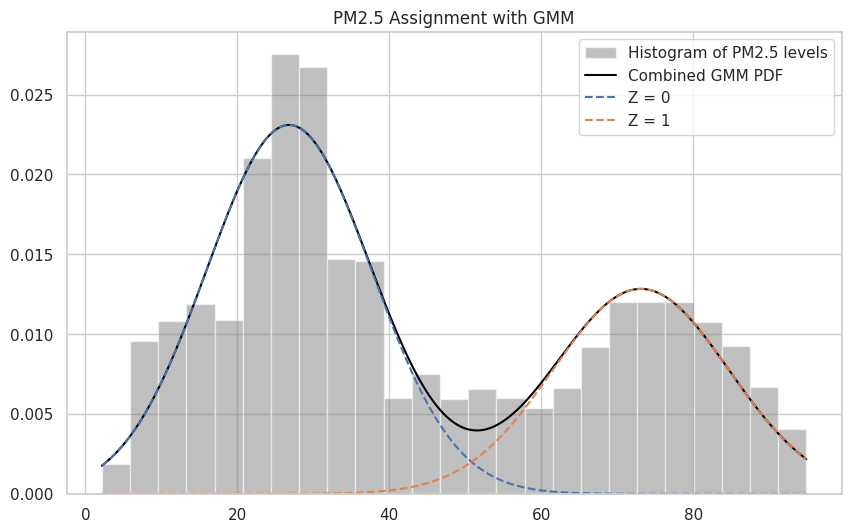

In [45]:
pm_gmm = df['DS_PM_pred'].to_numpy().reshape(-1, 1)

gmm = GaussianMixture(n_components=2, random_state=0)
gmm.fit(pm_gmm)

counts, bins, _ = plt.hist(pm_gmm, bins=25, density=True, alpha=0.5, color="gray", label="Histogram of PM2.5 levels")

x = np.linspace(pm_gmm.min(), pm_gmm.max(), 1000).reshape(-1, 1)
pdf = np.exp(gmm.score_samples(x))
plt.plot(x, pdf, label="Combined GMM PDF", color="black")

for i in range(2):
    mean = gmm.means_[i][0]
    std = np.sqrt(gmm.covariances_[i][0][0])
    weight = gmm.weights_[i]
    component_pdf = weight * (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mean) / std) ** 2)
    plt.plot(x, component_pdf, "--", label=f"Z = {i}")

plt.legend()
plt.title("PM2.5 Assignment with GMM")
plt.show()

In [46]:
assignments = np.argmax(gmm.predict_proba(pm_gmm), axis=1)
df["Treatment_GMM"] = assignments

Text(0, 0.5, 'Asthma prevalence')

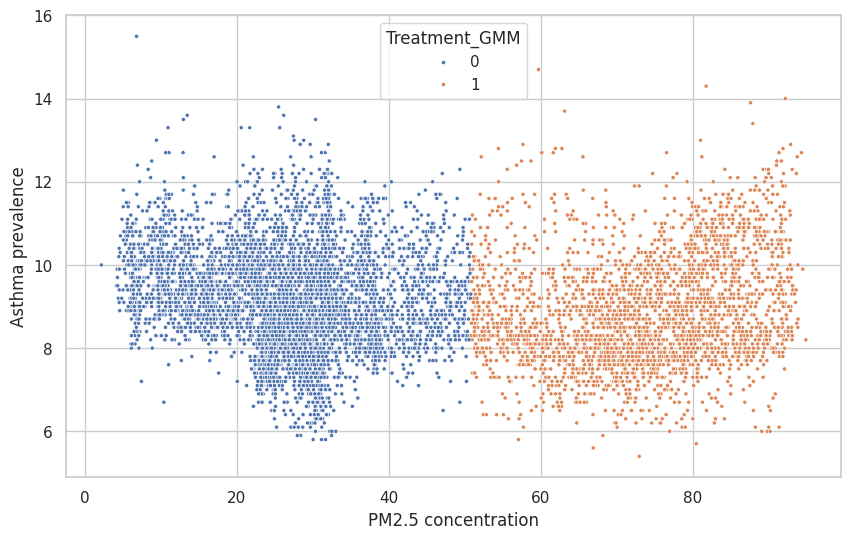

In [47]:
sns.scatterplot(data=df, x="DS_PM_pred", y="Data_Value", marker=".", hue="Treatment_GMM")
plt.xlabel("PM2.5 concentration")
plt.ylabel("Asthma prevalence")

Text(0.5, 0, 'Asthma prevalence')

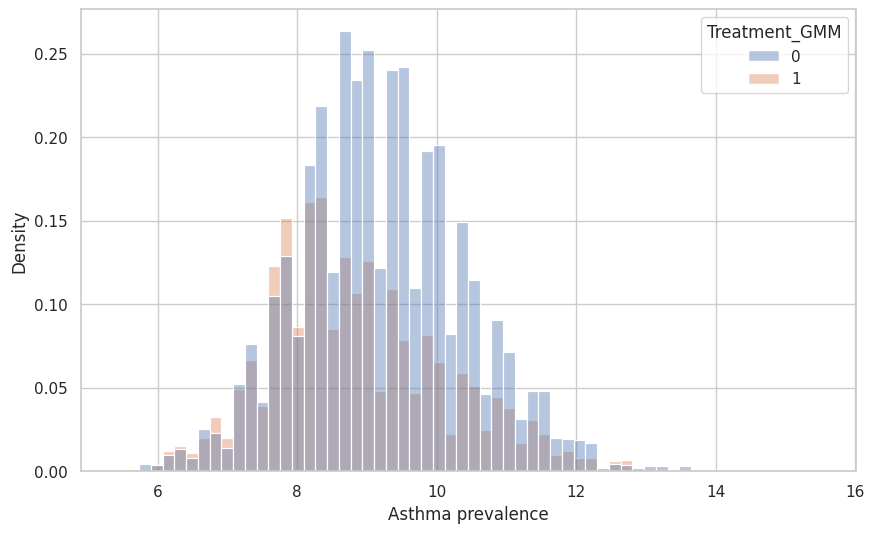

In [48]:
sns.histplot(data=df, stat="density", x="Data_Value", hue="Treatment_GMM", alpha=0.4)
plt.xlabel("Asthma prevalence")

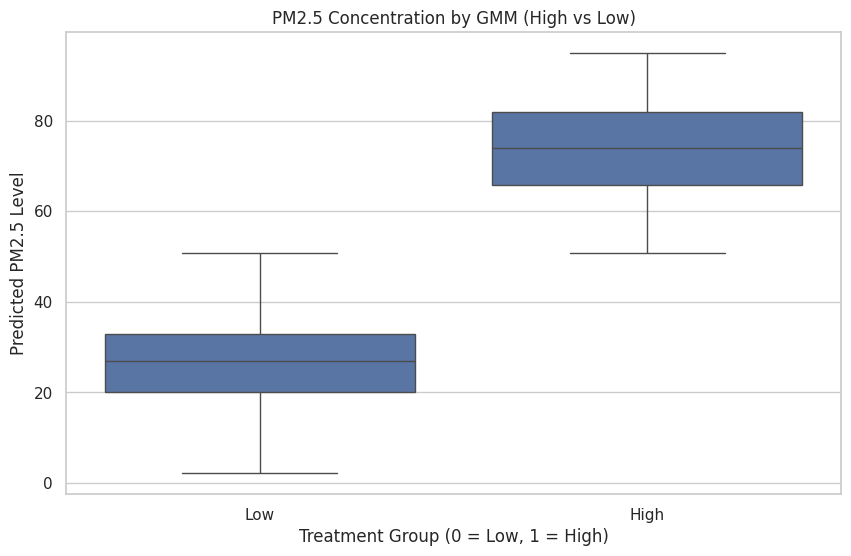

In [49]:
sns.boxplot(x='Treatment_GMM', y='DS_PM_pred', data=df)

plt.title('PM2.5 Concentration by GMM (High vs Low)')
plt.xlabel('Treatment Group (0 = Low, 1 = High)')
plt.ylabel('Predicted PM2.5 Level')
plt.xticks([0, 1], ['Low', 'High'])

plt.show()

Observations:

The plot clearly confirms that your PM2.5 clustering (into “High” and “Low”) is meaningful and distinct. The median PM2.5 level in the high cluster is substantially higher (around 75) than in the low cluster (around 28). There is little overlap in interquartile ranges (IQRs), which suggests strong separation between the two groups.

Relevance to Questions:

Q1: This clustering provides a binary treatment variable (High vs. Low PM2.5) necessary for methods like Inverse Propensity Weighting or matching. It validates that the treatment is not arbitrary—we’re distinguishing areas that truly differ in pollution exposure. This setup helps us estimate the causal effect of high PM2.5 on asthma while adjusting for confounders like race or gender.

<div style="page-break-after: always;"></div>

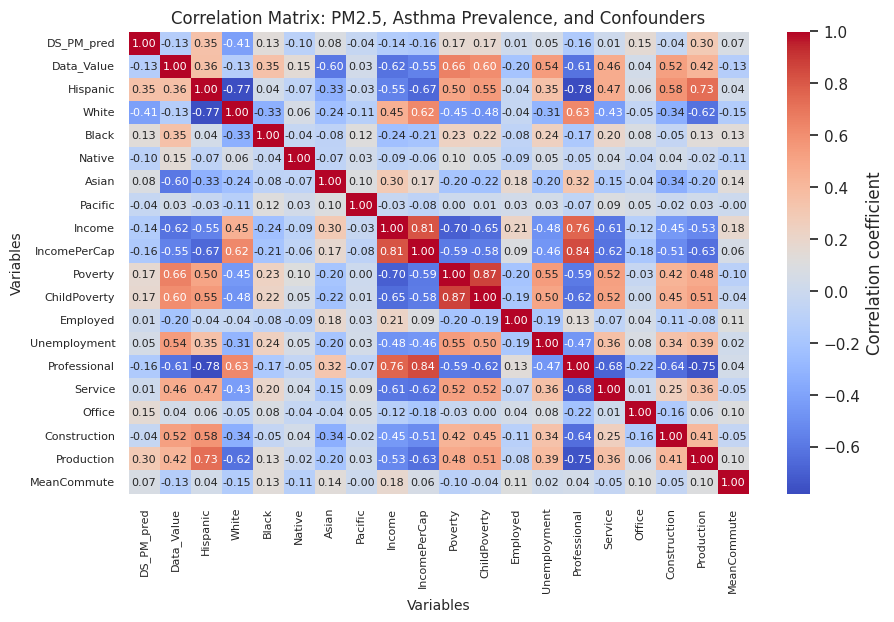

In [50]:
confounders = ['Hispanic', 'White', 'Black', 'Native', 'Asian', 'Pacific', 'Income', 'IncomePerCap',
               'Poverty', 'ChildPoverty', 'Employed', 'Unemployment', 'Professional',
               'Service', 'Office', 'Construction', 'Production', 'MeanCommute']

correlations = df[['DS_PM_pred', 'Data_Value'] + confounders].corr()
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8},
            cbar_kws={'label': 'Correlation coefficient'})
plt.title("Correlation Matrix: PM2.5, Asthma Prevalence, and Confounders", fontsize=12)
plt.xlabel('Variables', fontsize=10)
plt.ylabel('Variables', fontsize=10)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)
plt.show()

Observations:

The first potential confounder is production, which are correlated with both income and asthma, which may influence modeling assumptions. Poverty and income are highly inversely correlated (-0.70), which is expected.

PM2.5 has negative correlation with income (-0.14), professional employment (-0.16). Positive correlation with poverty (0.17) and production sector employment (0.30). Suggests that lower-income, industrial communities may have higher pollution levels.

Relevance to Questions:

Q1: The matrix supports the presence of important confounders: prodcution, income, poverty, and race (Hispanic) are related both to PM2.5 exposure and asthma prevalence. These need to be carefully controlled for or stratified in causal models like IPW or matching.

Q2: Strong correlations with race (Hispanic), poverty, and employment sectors suggest that socioeconomic and demographic variables are informative predictors of pollution. We might consider feature selection guided by these correlations, and using regularization if multicollinearity becomes a modeling issue.

<div style="page-break-after: always;"></div>

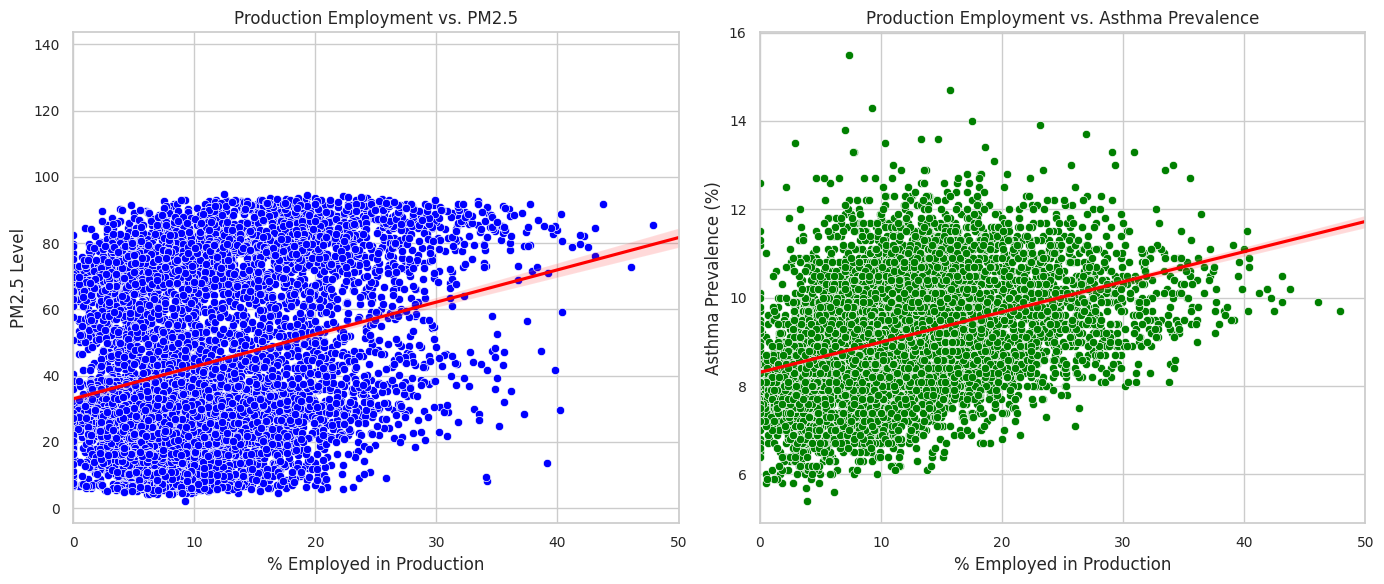

In [51]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=df, x='Production', y='DS_PM_pred', ax=axs[0], color='blue')
sns.regplot(data=df, x='Production', y='DS_PM_pred', ax=axs[0], scatter=False, color='blue', line_kws={'color': 'red'})
axs[0].set_title('Production Employment vs. PM2.5')
axs[0].set_xlabel('% Employed in Production')
axs[0].set_ylabel('PM2.5 Level')
axs[0].set_xlim(0, 50)
axs[0].tick_params(axis='both', which='major', labelsize=10)

sns.scatterplot(data=df, x='Production', y='Data_Value', ax=axs[1], color='green')
sns.regplot(data=df, x='Production', y='Data_Value', ax=axs[1], scatter=False, color='green', line_kws={'color': 'red'})
axs[1].set_title('Production Employment vs. Asthma Prevalence')
axs[1].set_xlabel('% Employed in Production')
axs[1].set_ylabel('Asthma Prevalence (%)')
axs[1].set_xlim(0, 50)
axs[1].tick_params(axis='both', which='major', labelsize=10)


plt.tight_layout()
plt.show()

Observations:

More industrial/production-based employment in an area is associated with higher predicted PM2.5 levels. This makes sense since industrial activity is a key source of particulate pollution. Areas with more production jobs lead to higher PM2.5, then higher asthma prevalence. This fits neatly into the causal chain.

Relevance to Questions:

Q1: These plots motivate the hypothesis that production-heavy areas may suffer worse asthma outcomes via increased pollution. Also motivates controlling for employment type in your causal analysis, as it may act as a confounder.

Q2: Since production employment is positively associated with PM2.5, it may serve as a predictive feature in our non-parametric models. Including sector-level employment variables could improve your model's socio-environmental interpretability.

<div style="page-break-after: always;"></div>

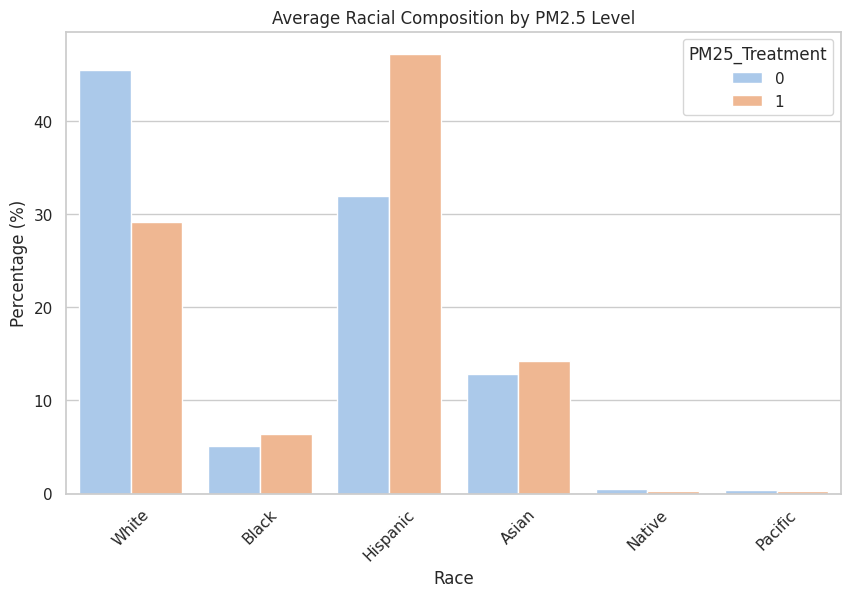

In [52]:
race_cols = ['White', 'Black', 'Hispanic', 'Asian', 'Native', 'Pacific']
race_df = df.groupby('PM25_Treatment')[race_cols].mean().reset_index().melt(id_vars='PM25_Treatment', var_name='Race', value_name='Percentage')

sns.barplot(data=race_df, x='Race', y='Percentage', hue='PM25_Treatment', palette='pastel')
plt.title("Average Racial Composition by PM2.5 Level")
plt.xticks(rotation=45)
plt.ylabel("Percentage (%)")
plt.show()

Observations:

Hispanic and Black populations are overrepresented in high PM2.5 areas. White populations are more prevalent in low PM2.5 areas. Asian representation is similar across both, but with slight variation.

Relevance to Both Questions:

This supports the idea that race/ethnicity is a confounding factor: differences in asthma prevalence could reflect environmental injustice, not just pollution. It justifies adjusting for race/ethnicity in both causal and predictive models. Also suggests structural disparities that could be a focus in policy-oriented discussions.


----------
----------

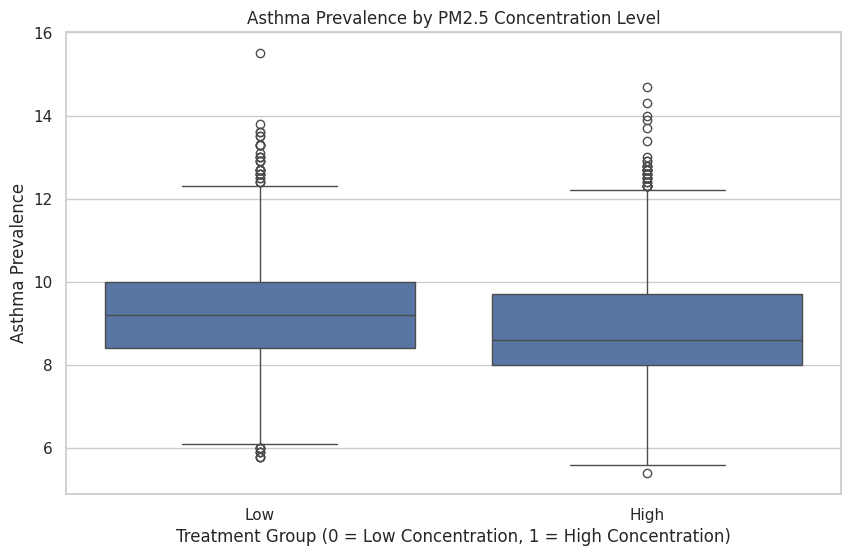

In [53]:
sns.boxplot(x='Treatment_GMM', y='Data_Value', data=df)

plt.title('Asthma Prevalence by PM2.5 Concentration Level')
plt.xlabel('Treatment Group (0 = Low Concentration, 1 = High Concentration)')
plt.ylabel('Asthma Prevalence')
plt.xticks([0, 1], ['Low', 'High'])

plt.show()

In [54]:
# Drop rows where any confounder is missing
confounders = [
    "Income",
    "IncomePerCap",
    "Poverty",
    "ChildPoverty",
    "Professional",
    "Production",
    "Unemployment",
    "Hispanic",
    "Black",
    "Asian",
    "White",
    "Native",
    "MeanCommute"
]
df = df.dropna(subset=confounders)

# Create treatment variable: High_PM25 based on 75th percentile of DS_PM_pred
# q3_threshold = df["DS_PM_pred"].quantile(0.75)
# df["High_PM25"] = (df["DS_PM_pred"] > q3_threshold).astype(int)

# Set up X and y for propensity model
X = df[confounders]
y = df["Treatment_GMM"]

# Fit logistic regression to estimate propensity scores
ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(X, y)

# Predict propensity scores
df["propensity_score"] = ps_model.predict_proba(X)[:, 1]

# Preview results
df[["Treatment_GMM", "propensity_score"]].head()


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Treatment_GMM,propensity_score
0,0,0.220605
1,0,0.334162
2,0,0.453034
3,0,0.484344
4,0,0.343229


Should fix warning that logistic regression reached the max number of iterations and didn't fully converge by scaling the data or raising max_iter higher but it should be fine for checkpoint 2

In [55]:

df["ipw_weight"] = df["Treatment_GMM"] / df["propensity_score"] + (1 - df["Treatment_GMM"]) / (1 - df["propensity_score"])

df[["Treatment_GMM", "propensity_score", "ipw_weight"]].head()


,Treatment_GMM,propensity_score,ipw_weight
0,0,0.220605,1.283046
1,0,0.334162,1.501867
2,0,0.453034,1.828267
3,0,0.484344,1.939278
4,0,0.343229,1.522601


Applied inverse probability weighting (IPW) to adjust for confounding. Each census tract was weighted inversely proportional to its probability of receiving the treatment it actually received.

In [56]:
treated_mean = (df[df["Treatment_GMM"] == 1]["Data_Value"] * df[df["Treatment_GMM"] == 1]["ipw_weight"]).sum() / df[df["Treatment_GMM"] == 1]["ipw_weight"].sum()

control_mean = (df[df["Treatment_GMM"] == 0]["Data_Value"] * df[df["Treatment_GMM"] == 0]["ipw_weight"]).sum() / df[df["Treatment_GMM"] == 0]["ipw_weight"].sum()

ate = treated_mean - control_mean

print(f"Weighted mean Asthma Prevalence (High PM2.5): {treated_mean:.4f}")
print(f"Weighted mean Asthma Prevalence (Low PM2.5): {control_mean:.4f}")
print(f"Estimated Average Treatment Effect (ATE): {ate:.4f}")


Weighted mean Asthma Prevalence (High PM2.5): 8.7976
Weighted mean Asthma Prevalence (Low PM2.5): 9.1737
Estimated Average Treatment Effect (ATE): -0.3761


Used inverse probability weighting to estimate the causal effect of high PM2.5 exposure on asthma prevalence. The ATE represents the estimated difference in average asthma prevalence between high and low exposure census tracts after adjusting for confounding.

In our causal analysis, we investigated the effect of high PM2.5 exposure on adult asthma prevalence in California census tracts for the year 2018. We defined high exposure based on unsupervised clustering (using KMeans or Gaussian Mixture Models) of PM2.5 concentrations to seperate tracts into high and low exposure groups. To adjust for confounding, we estimated propensity scores using logistic regression based on socioeconomic and demographic variables, including income, poverty, race/ethnicity, employment type, and mean commute time. We then applied inverse probability weighting (IPW) to simulate a randomized expirement. After weighting, we found that the weighted average asthma prevalence in high PM2.5 tracts was 8.80%, while in low PM2.5 tracts it was 9.17%. The estimated averate treatment effect(ATE) was -0.38 percentage points.  

The ATE was negative which sugests that tracts identified of having higher PM2.5 concentrations actually had slightly lower asthma prevalence after adjusting for confounders. This result is unexpected, given prior research typically links higher air pollution to increased asthma rates. Possible explanations include unmeasured confounding inaccuracies in PM2.5 predictions, or limitations in the clusting method for treatment assignment. Future analyses could explore alternative causal modeling approaches or sensitivity analyses to assess the robustness of this finding.  

## Methods

Treatment: Being in a location with a high PM2.5 concentration. A Gaussian Mixture Model was used to fit two normal distributions to the bimodal distribution of PM2.5 concentrations, then using the two new distributions to assign each data point to the low or high concentration groups.

Outcome: Asthma prevalence.

Confounders: Income, income per capita, poverty levels, child poverty levels, race demographics, unemployment levels, employment type, and mean commute time. Inverse Propensity Weighting (IPW) will be used to adjust for these confounders.

Colliders: None

DAG: See image below

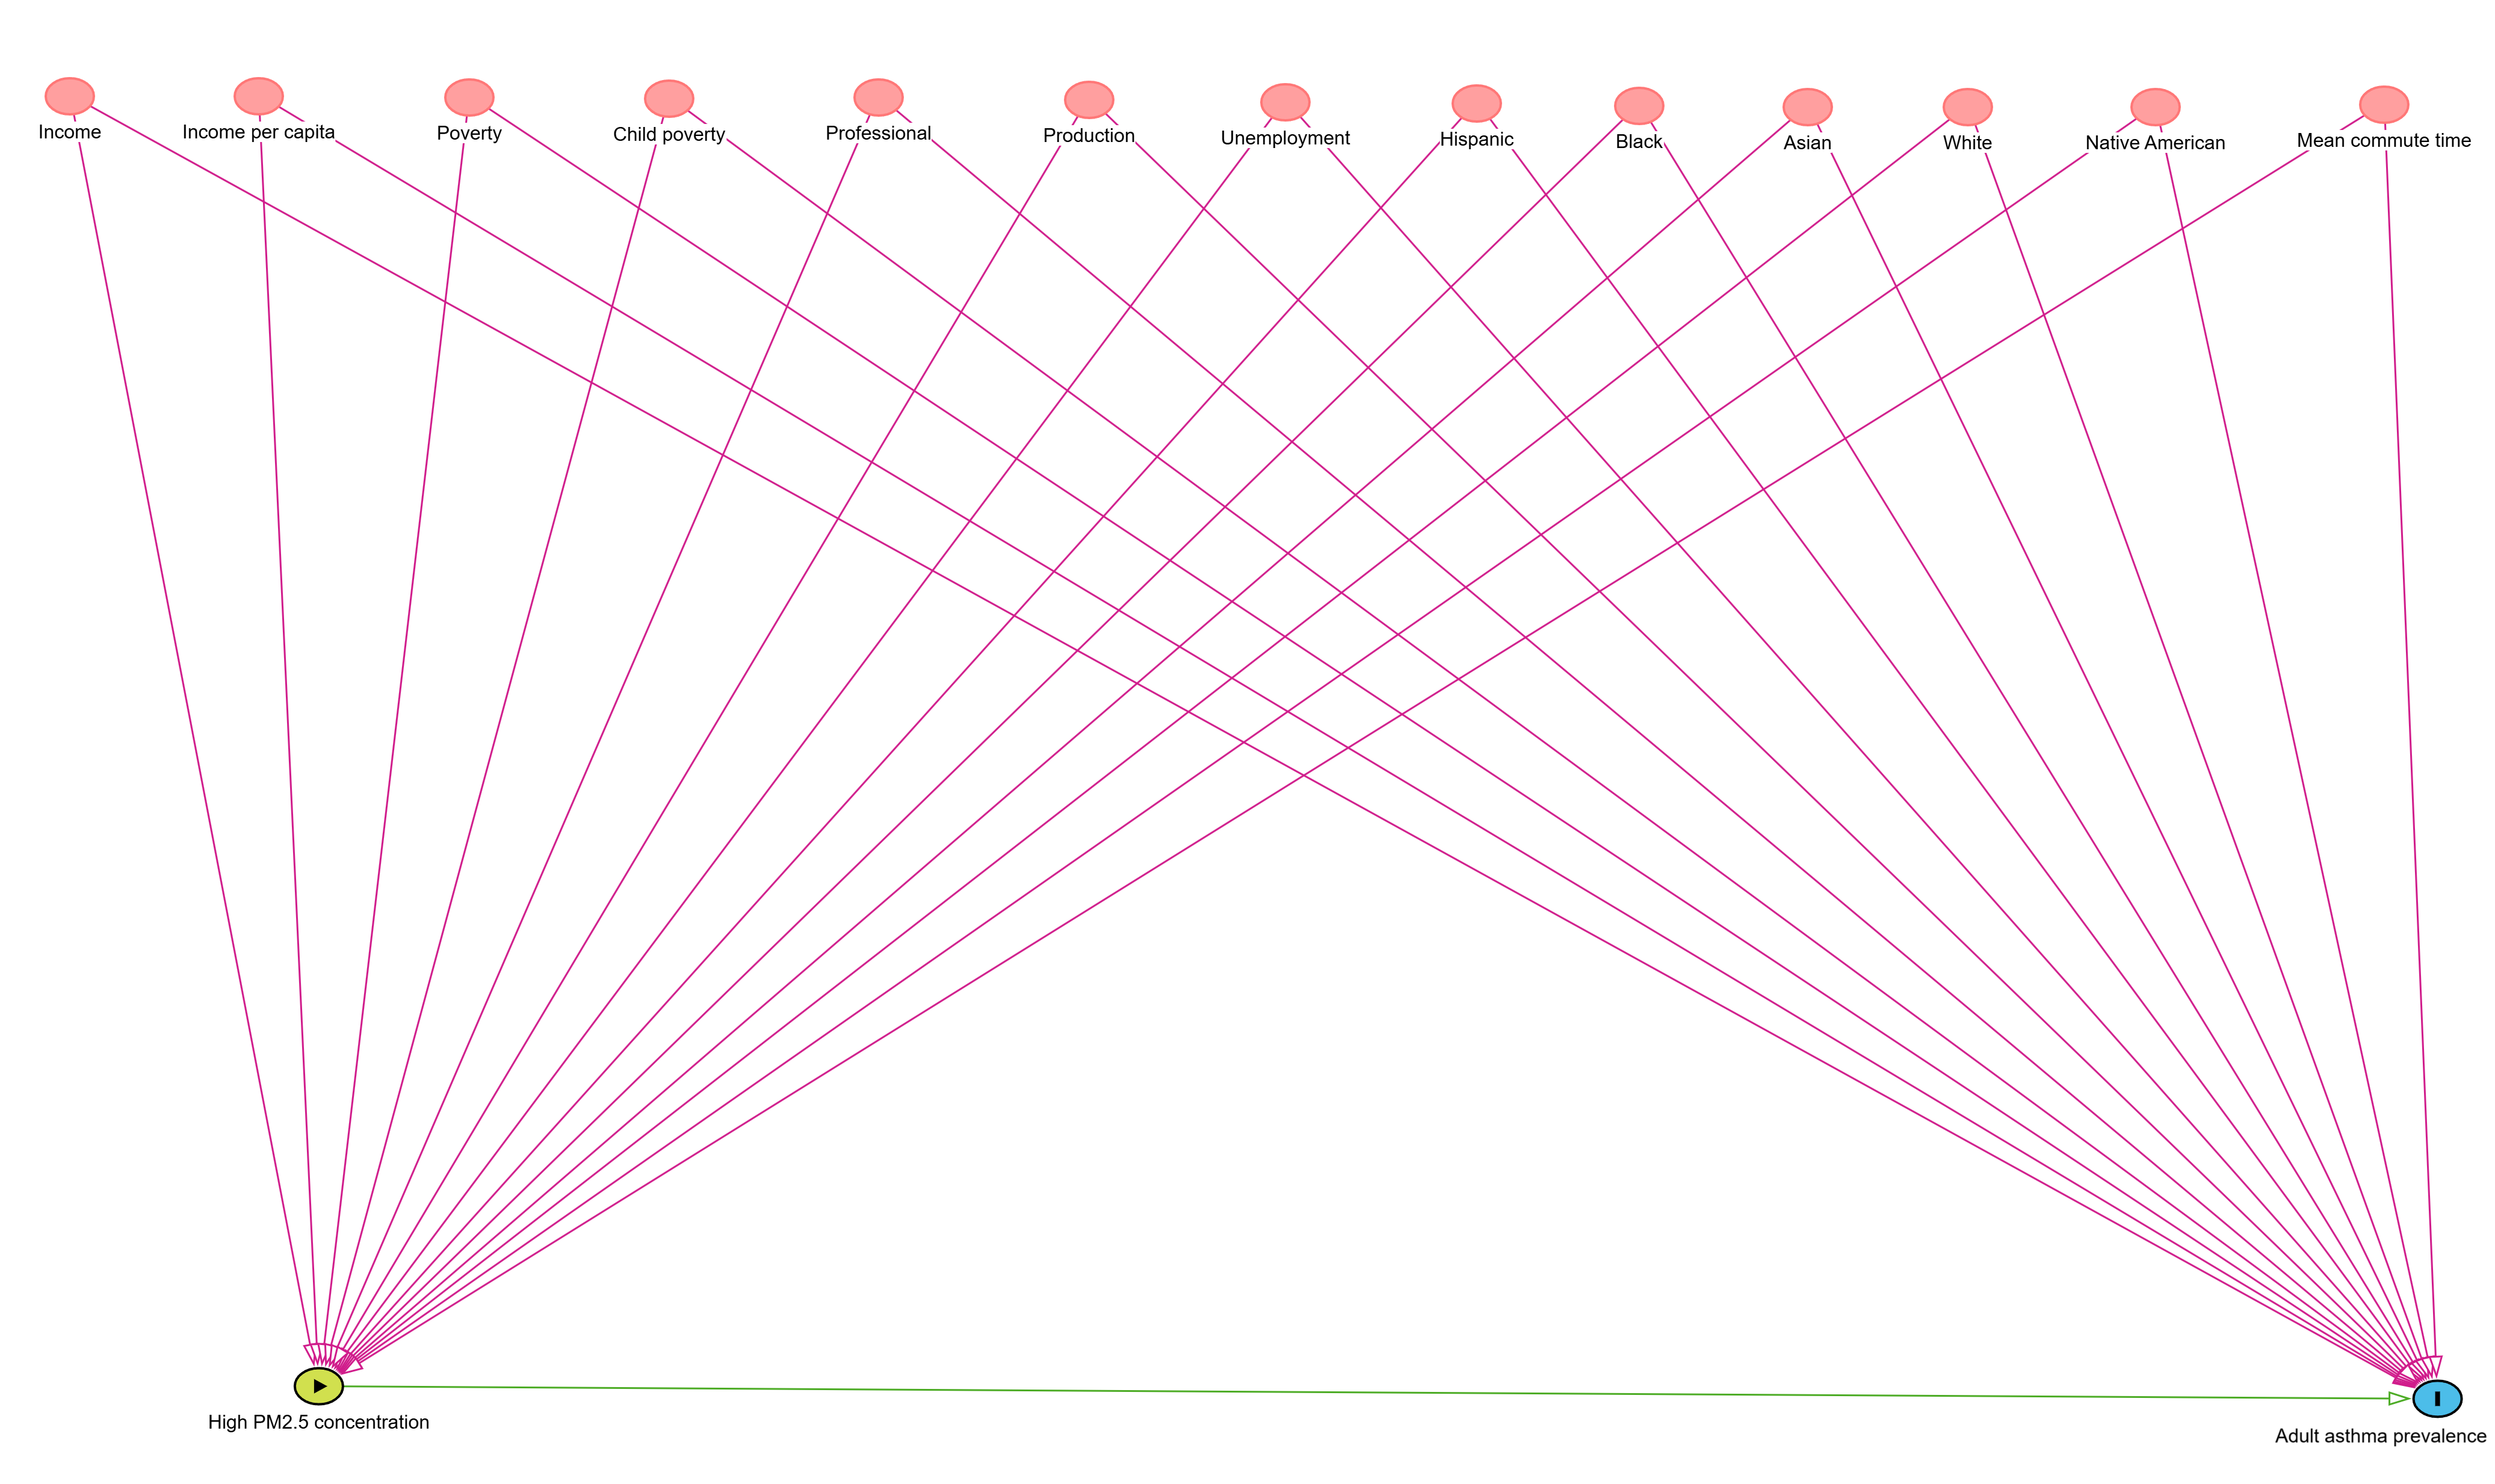

In [57]:
from IPython.display import Image
Image("dag_final.png")

## Results

After performing inverse propensity weighting to account for confounders, the estimated treatment effect of high PM2.5 concentration on adult asthma prevalence was found to be -0.3761. This indicates that a high PM2.5 concentration in an area decreases its asthma prevalence by about 0.38%.

However, the statistical significance of this small value might be overshadowed by the uncertainties in this experiment, such as any that might be introduced through biases in the data. It is therefore not clear that there is any causal relationship between PM2.5 levels and asthma prevalence.

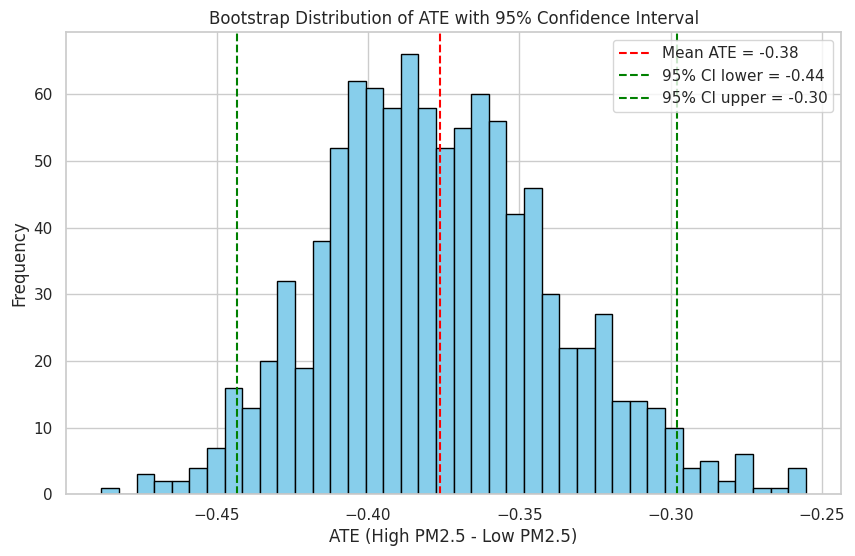

In [58]:
df_boot = df.dropna(subset=["Data_Value", "ipw_weight", "Treatment_GMM"])

n_bootstraps = 1000
bootstrap_ates = []

for _ in range(n_bootstraps):
    sample = df_boot.sample(frac=1, replace=True)
    treated = sample[sample["Treatment_GMM"] == 1]
    control = sample[sample["Treatment_GMM"] == 0]

    treated_mean = (treated["Data_Value"] * treated["ipw_weight"]).sum() / treated["ipw_weight"].sum()
    control_mean = (control["Data_Value"] * control["ipw_weight"]).sum() / control["ipw_weight"].sum()

    bootstrap_ates.append(treated_mean - control_mean)

ci_lower = np.percentile(bootstrap_ates, 2.5)
ci_upper = np.percentile(bootstrap_ates, 97.5)
ate_point_estimate = np.mean(bootstrap_ates)

plt.figure(figsize=(10, 6))
plt.hist(bootstrap_ates, bins=40, color="skyblue", edgecolor="black")
plt.axvline(ate_point_estimate, color="red", linestyle="--", label=f"Mean ATE = {ate_point_estimate:.2f}")
plt.axvline(ci_lower, color="green", linestyle="--", label=f"95% CI lower = {ci_lower:.2f}")
plt.axvline(ci_upper, color="green", linestyle="--", label=f"95% CI upper = {ci_upper:.2f}")
plt.title("Bootstrap Distribution of ATE with 95% Confidence Interval")
plt.xlabel("ATE (High PM2.5 - Low PM2.5)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


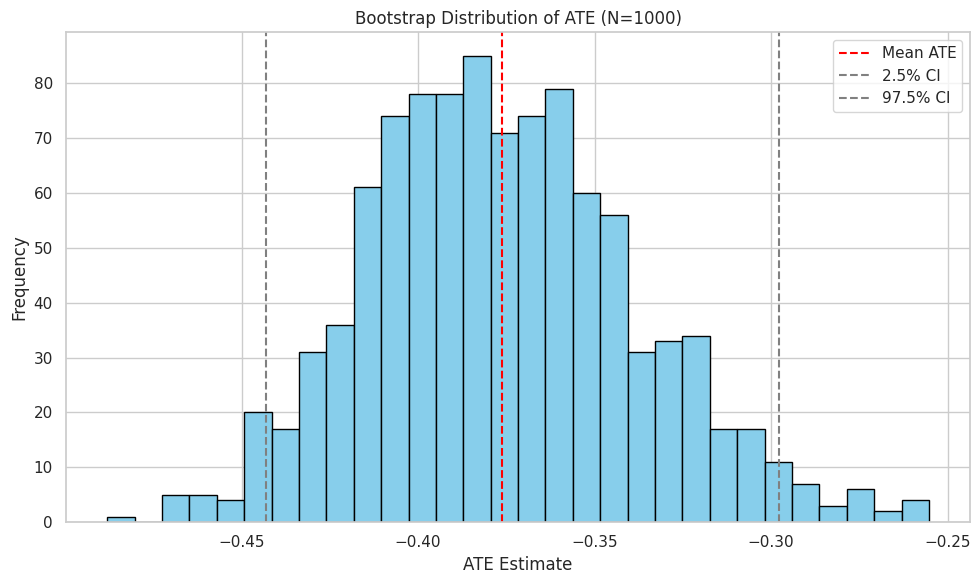

In [59]:
import matplotlib.pyplot as plt

plt.hist(bootstrap_ates, bins=30, color='skyblue', edgecolor='black')
plt.axvline(np.mean(bootstrap_ates), color='red', linestyle='--', label='Mean ATE')
plt.axvline(np.percentile(bootstrap_ates, 2.5), color='gray', linestyle='--', label='2.5% CI')
plt.axvline(np.percentile(bootstrap_ates, 97.5), color='gray', linestyle='--', label='97.5% CI')
plt.xlabel("ATE Estimate")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of ATE (N=1000)")
plt.legend()
plt.tight_layout()
# plt.savefig("bootstrap_hist.png", dpi=300)

In [60]:
# from google.colab import files
# files.download("bootstrap_hist.png")


To quanitfy undcertainty in our causal estimate, we applied a bootstrap procedure using 1,000 samples. For each sample, we recalculated the inverse provavility weighted ATE of high PM2.5 exposure on asthma prevalence. The resulting distribution of ATE's is shown in the histogram above. From this, we calculated a 95% confidence interval ranging from -0.45 to -0.30 percentage points, with mean ATE of -0.37. This interval provides evidence that the estimated effect is statistically distinguishable from zero, even though its direction is counterintuitive.  The bootstrapping adds robustness to our causal analysis by showing our result is consitent across repeated sampling, and helps communicated the degree of uncertainty surrounding our estimate.  

After reviewing DAG to check for colliders all adjustment variables, including income, race/ethnicity, and employment characteristics, are pretreatment confounders rather than coliders.  No collider variables are included in propesnity score model which helps ensure the validity of our causal effect estimation.

## Discussion

Our causal analysis investigated the effect of high PM2.5 exposure on adult asthma prevalence in California census tracts, using IPW to adjust for confounding. After adjusting for socioeconmic, demographic, and geographic confouners, including income, poverty, race/ethnicity, employment type, and commute patterns, we estimated a statisticaly significant ATE of about -0.38 percentage points, with a 95% confidence interval of [-0.45, -0.30] based on 1,000 bootstrap samples.  

The estimate effect was negative which indicates that tracts with higher PM2.5 exposure had slightly lower asthma prevalence than those with lower exposure after adjustment.  This contradicts the typical assumption that associatesa air pollution with increased respiratory risk.  Several explanations are possible.  First, our use of clusterin-based treatment definitions may not fully align with health-relevant exposure levels.  Second unmeasured confounding such as housing quality, access to meical care, or differences in population sensitivity, may bias the results.  Third structural facors like urbanization may create inverse associations (tracts with high PM2.5 may also have better infrastructure and healthcare access, making underlying risks)

Finally, our analysis assumes the validity of the unconfoundedness assumption given our selected covariates, and that the propensity score model is correctly specified.  While we took care to avoid adjusting for colliders and used a DAG to support our assumptions, further robustness checks using alternative causal methods or sensitivity analysis would strenghten the conclusins.  We also recognize that our data is cross-sectional and ecological, limiting individual-level causal clams.

Overall, while our findings were not aligned with initial hypotheses, they provide a foundation for further exploration and illustrate the importance of critically evaluation modeling assumptions in observational causal inference.  